In [2]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pypalettes import load_cmap
palette = "Arches"
cmap = load_cmap(palette).colors

categorical = sns.color_palette([x for x in load_cmap(palette).colors if x!='#682C37FF'], 4)

In [3]:
MEDIUM_SIZE = 22
BIGGER_SIZE = 22

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [4]:
with open("frame_answers.pkl", "rb") as f:
    frame_results = pickle.load(f)

In [5]:
with open("frame_answers_reranked.pkl", "rb") as f:
    frame_results_reranked = pickle.load(f)

In [6]:
answers = pd.read_csv("frame_df.csv")

In [7]:
reranked = pd.read_csv("frame_df_reranked.csv")

In [8]:
len(answers), len(frame_results)

(10047, 10047)

In [9]:
len(reranked), len(frame_results_reranked)

(419, 419)

In [10]:
all_frames = []
models = []
conditions = []
languages = []
for f, condition, model, language in zip(frame_results, answers["condition"], answers["model"], answers['language']):
    for frame in f.frames:
        # print(frame.name)
        # for elem in frame.frame_elements:
        #     print(f"{elem.name}: {elem.text}")
        # print()
        all_frames.append(frame.name)
        models.append(model)
        languages.append(language)
        conditions.append("rag" if "rag" in condition else "baseline")

In [11]:
frame_namesdf_allmodels = pd.DataFrame({"framename": all_frames, "condition":conditions, "Language":languages})
all_frames_count = frame_namesdf_allmodels.groupby(by=["framename", "condition", "Language"]).value_counts().reset_index(name="count")

In [12]:
rag = all_frames_count[all_frames_count["condition"]=="rag"].sort_values(by=["framename"], ascending=False).set_index("framename").drop("condition", axis=1)
baseline = all_frames_count[all_frames_count["condition"]=="baseline"].sort_values(by=["framename"], ascending=False).set_index('framename').drop("condition", axis=1)

C:\Users\imruh\AppData\Local\Temp\ipykernel_76500\3453447494.py:14: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.barplot(


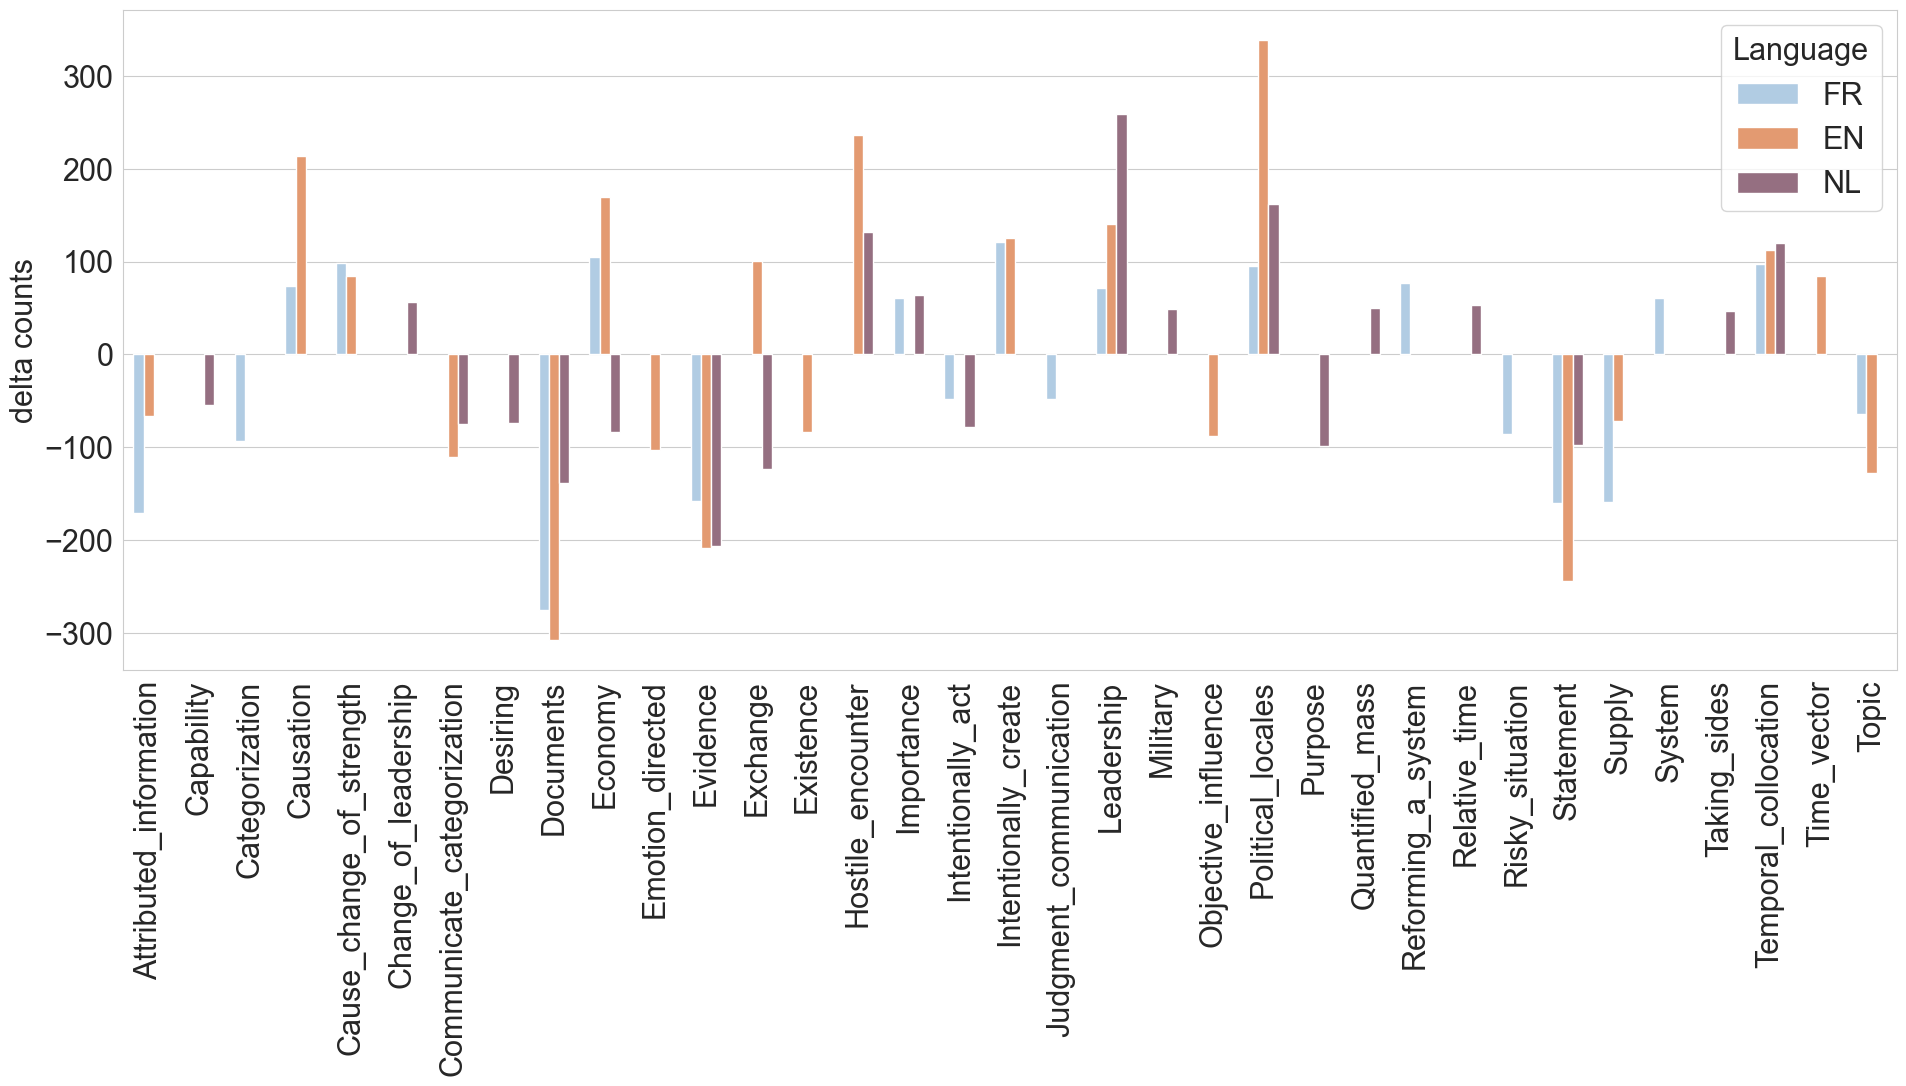

In [13]:
all_lang_chosen = pd.DataFrame()
for i, language in enumerate(["EN", "FR", "NL"]):
    sub_baseline = baseline[baseline["Language"]==language].drop("Language", axis=1)
    sub_rag = rag[rag["Language"]==language].drop("Language", axis=1)
    diff = sub_baseline-sub_rag
    chosen1 = diff.fillna(0).sort_values(by="count", ascending=False)[:10]
    chosen2 = diff.fillna(0).sort_values(by="count", ascending=True)[:10]
    all_chosen = pd.concat([chosen1, chosen2.sort_values(by="count", ascending=False)]).reset_index()
    all_chosen["Language"] = language
    all_lang_chosen = pd.concat([all_lang_chosen, all_chosen])
    
all_lang_chosen = all_lang_chosen.reset_index().sort_values(by="framename")
plt.figure(figsize=(20,8))
g = sns.barplot(
    data=all_lang_chosen,
    x="framename", y="count", hue="Language", orient="v", palette=categorical, width=0.6,
    # color=cmap[i]
)
plt.tight_layout()
plt.grid(True, axis='y') 
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("delta counts")
plt.savefig("figs/frame_counts_v.svg")

In [14]:
all_lang_chosen[all_lang_chosen["framename"]=="Attributed_information"]

,index,framename,count,Language
38,18,Attributed_information,-171.0,FR
10,10,Attributed_information,-66.0,EN


C:\Users\imruh\AppData\Local\Temp\ipykernel_76500\3123296445.py:14: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.barplot(
C:\Users\imruh\AppData\Local\Temp\ipykernel_76500\3123296445.py:14: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.barplot(


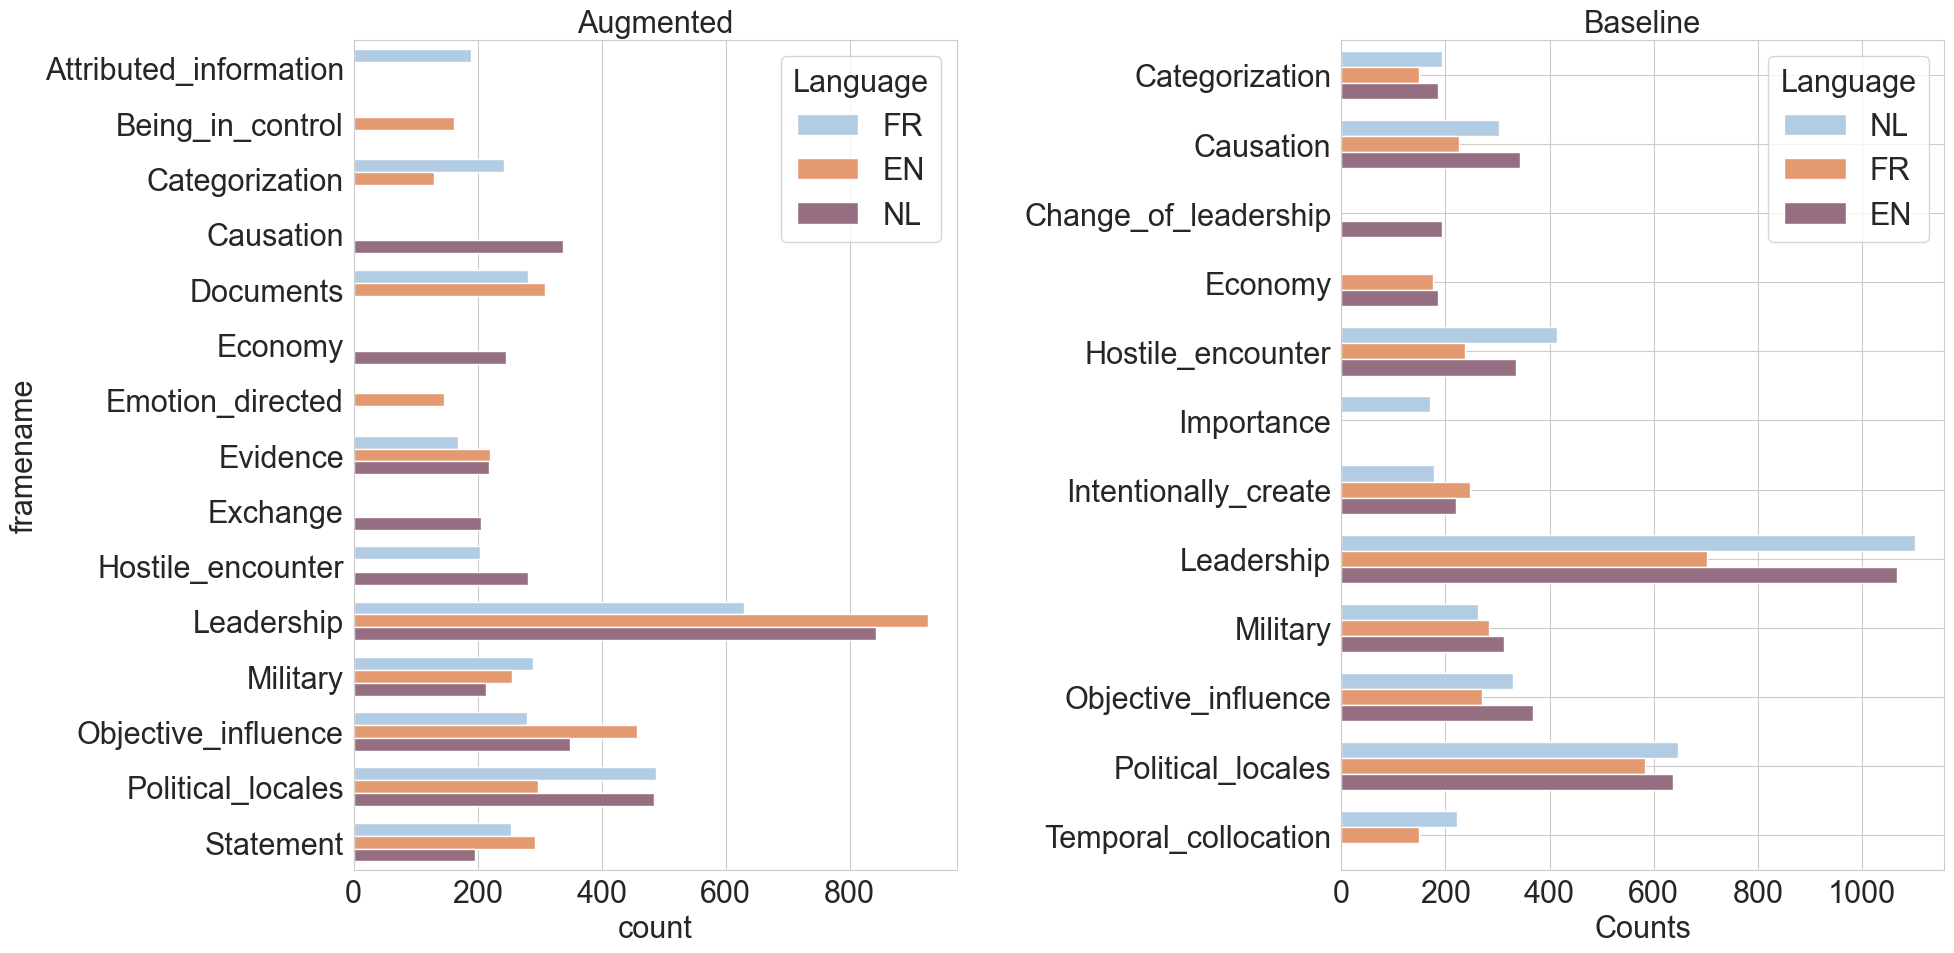

In [15]:
all_conditions = []
fig, axs = plt.subplots(1,2, figsize=(20,10))
idx = 0
for x, title in zip([rag, baseline], ['Augmented', 'Baseline']):
    all_lang_chosen_ = pd.DataFrame()
    for i, language in enumerate(["EN", "FR", "NL"]):
        sub = x[x["Language"]==language].drop("Language", axis=1)
        chosen1 = sub.fillna(0).sort_values(by="count", ascending=False)[:10]
        all_chosen = chosen1.reset_index()
        all_chosen["Language"] = language
        all_lang_chosen_ = pd.concat([all_lang_chosen_, all_chosen])
        all_lang_chosen_['condition'] = title
    all_conditions.append(all_lang_chosen_)
    g = sns.barplot(
        data=all_lang_chosen_.sort_values(by="framename"),
        y="framename", x="count", hue="Language", orient="h", palette=categorical, width=0.7, ax=axs[idx]
        # color=cmap[i]
    )
    axs[idx].set_title(title)
    idx+=1
plt.tight_layout()
plt.grid(True, axis='y') 
plt.xticks(rotation=0)
plt.ylabel("")
plt.xlabel("Counts")
plt.savefig("figs/frame_counts_top.svg")

In [16]:
test = pd.concat(all_conditions)
test = test.groupby(["framename","Language", 'condition']).agg("mean").reset_index().fillna(0)
test.pivot(index="framename", columns=['condition', "Language"], values="count").sort_index(axis=1, level=[0, 1]).fillna('-')

condition              Augmented               Baseline               
Language                      EN     FR     NL       EN     FR      NL
framename                                                             
Attributed_information         -  190.0      -        -      -       -
Being_in_control           162.0      -      -        -      -       -
Categorization             130.0  242.0      -    185.0  149.0   194.0
Causation                      -      -  337.0    343.0  227.0   303.0
Change_of_leadership           -      -      -    193.0      -       -
Documents                  309.0  282.0      -        -      -       -
Economy                        -      -  246.0    186.0  176.0       -
Emotion_directed           146.0      -      -        -      -       -
Evidence                   220.0  168.0  219.0        -      -       -
Exchange                       -      -  205.0        -      -       -
Hostile_encounter              -  204.0  282.0    336.0  237.0   414.0
Importance                     -      -      -        -      -   171.0
Intentionally_create           -      -      -    220.0  248.0   178.0
Leadership                 926.0  630.0  843.0   1067.0  702.0  1102.0
Military                   255.0  290.0  214.0    312.0  284.0   263.0
Objective_influence        457.0  279.0  349.0    369.0  270.0   330.0
Political_locales          297.0  488.0  484.0    636.0  583.0   646.0
Statement                  292.0  253.0  195.0        -      -       -
Temporal_collocation           -      -      -        -  150.0   222.0

In [31]:
all_frames = []
languages = []
for f, language in zip(frame_results, reranked['language']):
    for frame in f.frames:
        all_frames.append(frame.name)
        languages.append(language)

In [32]:
frame_namesdf_reranked = pd.DataFrame({"framename": all_frames, "Language":languages})

In [33]:
all_frames_count = frame_namesdf_reranked.groupby(by=["framename", "Language"]).value_counts().reset_index(name="count").sort_values(by=["framename"], ascending=False).set_index("framename")

In [35]:
all_lang_chosen_ = pd.DataFrame()
for i, language in enumerate(["EN", "FR", "NL"]):
    sub = all_frames_count[all_frames_count["Language"]==language].drop("Language", axis=1)
    chosen1 = sub.fillna(0).sort_values(by="count", ascending=False)[:5]
    print(chosen1)
    all_chosen = chosen1.reset_index()
    all_chosen["Language"] = language
    all_lang_chosen_ = pd.concat([all_lang_chosen_, all_chosen])

                     count
framename                 
Leadership              75
Political_locales       67
Hostile_encounter       42
Objective_influence     36
Exchange                30
                     count
framename                 
Hostile_encounter       70
Objective_influence     66
Economy                 61
Exchange                59
Causation               57
                     count
framename                 
Objective_influence     63
Hostile_encounter       60
Causation               39
Economy                 37
Political_locales       35


In [42]:
test = all_lang_chosen_.groupby(["framename","Language"]).agg("mean").reset_index().fillna(0)
test.pivot(index="framename", columns="Language", values="count").sort_index(axis=1, level=[0, 1]).fillna('-')

Language,EN,FR,NL
framename,,,
Causation,-,57.0,39.0
Economy,-,61.0,37.0
Exchange,30.0,59.0,-
Hostile_encounter,42.0,70.0,60.0
Leadership,75.0,-,-
Objective_influence,36.0,66.0,63.0
Political_locales,67.0,-,35.0
